
## Worst-of Call Option

A worst-of option is a multi-asset derivative whose payoff depends on the worst-performing asset in a basket.

This type of product is commonly used to illustrate the effects of dispersion in multi-asset options.

In this notebook, we consider a worst-of call option on two equity indices.

## Payoff Definition

Let $S_1(T), S_2(T), ..., S_n(T)$ be the terminal values of $n$ assets.

The payoff of a worst-of call option is given by:

$$
\text{Payoff} = \max\left( \min(S_1(T), S_2(T), ..., S_n(T)) - K, 0 \right)
$$

In this project, we work with normalized performance indices:

$$
\text{Payoff} = \max\left( \min(X_1(T), X_2(T)) - K, 0 \right)
$$


## Economic Intuition

A worst-of call option depends on the worst-performing asset in the basket.

Even if one asset performs well, the payoff is driven by the weakest one:

$$
\min(X_1(T), X_2(T))
$$

As a result, the payoff is more penalized than for a standard call option, making the worst-of call cheaper.

In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.random as npr
import yfinance as yf




## Pricing Framework

The option is priced using a Monte Carlo simulation under a bivariate Black-Scholes model.

- The assets follow correlated geometric Brownian motions
- Volatilities and correlation are estimated from historical data
- The payoff is computed at maturity
- Results are expressed as a percentage of notional

**Simplifications / limitations:**
- Dividend yields are not accounted for. For dividend-paying ETFs (SPY, EFA), the correct drift under risk-neutral measure is $r - q$, where $q$ is the continuous dividend yield. Omitting $q$ overstates the forward price and therefore slightly overestimates the option price.
- Historical (realized) volatility and correlation are used instead of implied. In practice, a market-consistent valuation would require implied volatility surfaces and implied correlation.

This approach provides an indicative price rather than a fully market-consistent valuation.

In [217]:
def download_prices(tickers, start_date, end_date):
    """Downloads adjusted closing prices and returns a clean DataFrame."""
    prices = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        interval="1d",
        auto_adjust=False,
        progress=False,
    )["Adj Close"]
    return prices

def hist_param(prices, M):
    rets = np.log(prices/prices.shift(1)).dropna()
    sigmas = rets.std(axis=0, ddof=1) * np.sqrt(M)
    corr = rets.corr()
    return rets, sigmas, corr


def worst_of_call_price( K, T, r, sigma1, sigma2, rho, I=100_000, seed=42):

    npr.seed(seed)

    # correlation matrix & cholesky decomposition
    corr_mat = np.array([[1, rho],
                         [rho, 1]])
    cho_mat = np.linalg.cholesky(corr_mat)

    # correlated standard normals — direct to maturity
    Z = npr.standard_normal((2, I))
    ran_corr = cho_mat @ Z

    # terminal prices under Black-Scholes
    perf1 = np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * ran_corr[0])
    perf2 =  np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * ran_corr[1])

    # Worst-of payoff
    worst = np.minimum(perf1, perf2)
    payoff = np.maximum(worst - K, 0)

    # Discounted expected payoff and confidence interval
    discount = np.exp(-r * T)
    price = discount * np.mean(payoff)
    std_error = discount * np.std(payoff, ddof=1) / np.sqrt(I)
    lb = price - 1.96 * std_error
    ub = price + 1.96 * std_error
    moneyness = "ATM" if np.isclose(K, 1.0) else ("ITM" if K < 1.0 else "OTM")

    return {
        "Monte Carlo Price": price,
        "MC Standard Error": std_error,
        "95% CI Lower": lb,
        "95% CI Upper": ub,
        "Number of Simulations": I,
        "Moneyness": moneyness,
        "Maturity (Years)": T,
        "Correlation (rho)": rho,
        "Volatility SPY": sigma1,
        "Volatility EFA": sigma2,
        }

In [218]:
# Parameters Pricing

K = 1.00
T = 1.00
r = 0.05
I = 100_000

tickers = ["SPY", "EFA"]
start_date = "2023-01-01"
end_date = "2025-12-31"
M = 252


## Market Data

We use historical price data for SPY and EFA as proxies for US and international equity markets.

Prices are downloaded and normalized to analyze their relative performance over time.

In [219]:

prices = download_prices(tickers, start_date, end_date)
prices_normalized = prices / prices.iloc[0] * 100

print(f"Periods : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Number of observations : {len(prices):,}")
prices.tail()

Periods : 2023-01-03 to 2025-12-30
Number of observations : 751


Ticker,EFA,SPY
Date,,
2025-12-23,96.290001,686.086304
2025-12-24,96.410004,688.499695
2025-12-26,96.570000,688.429871
2025-12-29,96.279999,685.976562
2025-12-30,96.440002,685.138916


## Historical Performance of Underlyings

The following chart shows the normalized performance of the two assets.

We observe that both assets follow similar trends but exhibit periods of divergence, which is key for worst-of products.

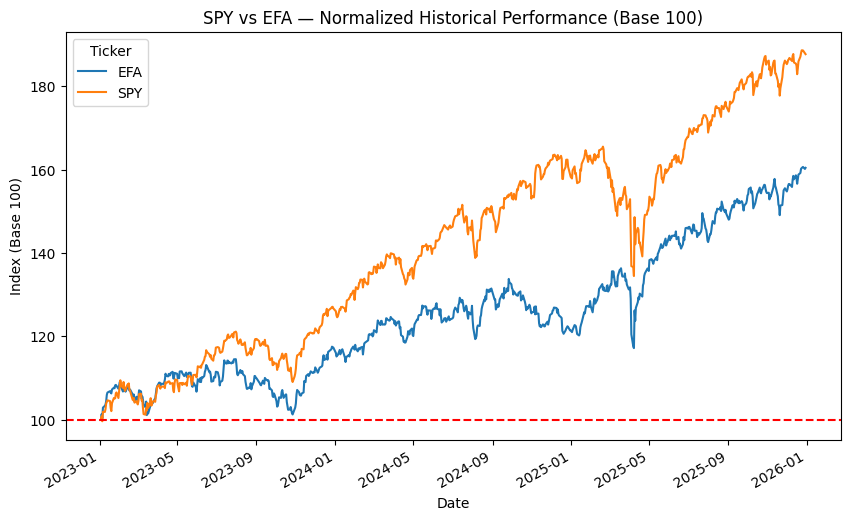

In [220]:
figure = prices_normalized.plot(figsize=(10, 6))
figure.axhline(100, linestyle="--", color="r")
figure.set_title("SPY vs EFA — Normalized Historical Performance (Base 100)")
figure.set_ylabel("Index (Base 100)")

plt.show()


## Returns and Distribution Analysis

We analyze daily log returns to estimate volatility and understand the statistical properties of the assets.

The distributions appear roughly symmetric but exhibit some tail events, which are important for option pricing.

## Model Calibration

Volatilities and correlation are estimated from historical log returns.

These parameters are used as inputs in the Monte Carlo pricing model.

Correlation plays a central role in the valuation of worst-of options.

In [221]:
rets, sigmas, corr = hist_param(prices, M)

sigma1 = float(sigmas["SPY"])
sigma2 = float(sigmas["EFA"])
rho = float(corr.loc["SPY", "EFA"])

summary_df = pd.DataFrame({
    "Parameter": ["sigma_SPY", "sigma_EFA", "rho_SPY_EFA", "K", "T", "r", "n_sims"],
    "Value": [sigma1, sigma2, rho, K, T, r, I],
})
summary_df

,Parameter,Value
0,sigma_SPY,0.152875
1,sigma_EFA,0.143339
2,rho_SPY_EFA,0.757903
3,K,1.000000
4,T,1.000000
5,r,0.050000
6,n_sims,100000.000000


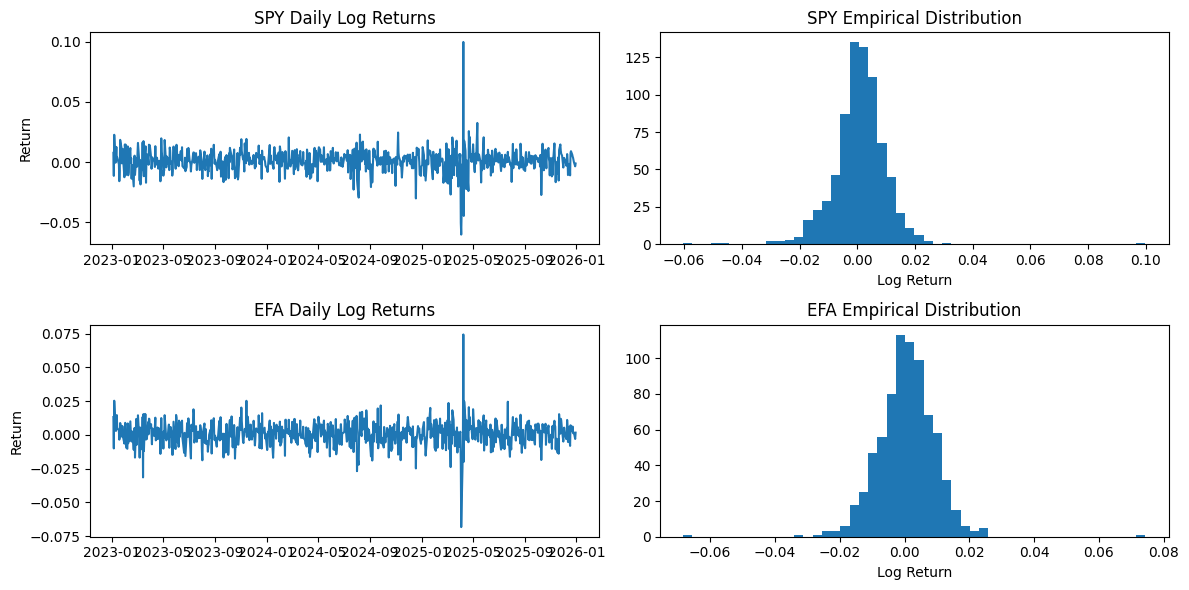

In [222]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].plot(rets.index, rets["SPY"], lw=1.5)
axes[0, 0].set_title("SPY Daily Log Returns")
axes[0, 0].set_ylabel("Return")

axes[1, 0].plot(rets.index, rets["EFA"], lw=1.5)
axes[1, 0].set_title("EFA Daily Log Returns")
axes[1, 0].set_ylabel("Return")

axes[0, 1].hist(rets["SPY"], bins=50)
axes[0, 1].set_title("SPY Empirical Distribution")
axes[0, 1].set_xlabel("Log Return")

axes[1, 1].hist(rets["EFA"], bins=50)
axes[1, 1].set_title("EFA Empirical Distribution")
axes[1, 1].set_xlabel("Log Return")

plt.tight_layout()
plt.show()


## Monte Carlo Pricing

The option is priced using a Monte Carlo simulation under a bivariate Black-Scholes framework.

Correlated normal variables are generated using a Cholesky decomposition of the correlation matrix.

The payoff is evaluated at maturity and discounted back to present value.


## Pricing Results

The Monte Carlo simulation provides an estimate of the option price along with a confidence interval.

The result is expressed as a percentage of the notional.

In [223]:
mc_res = worst_of_call_price(
    K=K,
    T=T,
    r=r,
    sigma1=sigma1,
    sigma2=sigma2,
    rho=rho,
    I=100_000,
    seed=42
)

df = pd.DataFrame(mc_res.items(), columns=["Metric", "Value"])
df


,Metric,Value
0,Monte Carlo Price,0.058336
1,MC Standard Error,0.000282
2,95% CI Lower,0.057784
3,95% CI Upper,0.058888
4,Number of Simulations,100000
5,Moneyness,ATM
6,Maturity (Years),1.0
7,Correlation (rho),0.757903
8,Volatility SPY,0.152875
9,Volatility EFA,0.143339


## Sensitivity to Correlation

The price of the worst-of call option is strongly dependent on correlation.

- Higher correlation reduces dispersion between assets
- Lower correlation increases dispersion and downside risk

Since the payoff depends on the worst-performing asset, increased dispersion reduces the expected payoff.

A buyer of this option is effectively **long correlation (short dispersion)**: the option gains value when assets are highly correlated and move together.

Note: it is the *issuer* who sells a worst-of structured note that is short correlation — not the buyer of the call.

             0         1        2         3         4         5         6   \
rho   -0.990000 -0.907500 -0.82500 -0.742500 -0.660000 -0.577500 -0.495000   
price  0.004273  0.006601  0.00873  0.010765  0.012763  0.014757  0.016771   

             7         8         9   ...        15        16        17  \
rho   -0.412500 -0.330000 -0.247500  ...  0.247500  0.330000  0.412500   
price  0.018824  0.020931  0.023081  ...  0.037408  0.040151  0.043067   

             18       19        20        21        22        23        24  
rho    0.495000  0.57750  0.660000  0.742500  0.825000  0.907500  0.990000  
price  0.046195  0.04958  0.053293  0.057484  0.062397  0.068638  0.079534  

[2 rows x 25 columns]


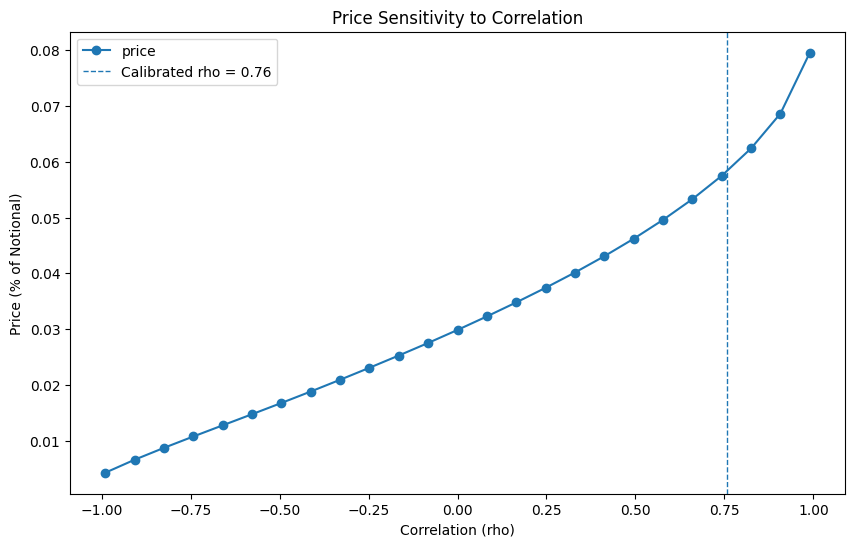

In [224]:
rho_list = np.linspace(-0.99, 0.99, 25)
rho_prices = []

for rhos in rho_list:
    mc_res = worst_of_call_price(
    K=K,
    T=T,
    r=r,
    sigma1=sigma1,
    sigma2=sigma2,
    rho=rhos,
    I=100_000,
    seed=42)
    rho_prices.append(mc_res["Monte Carlo Price"])

rho_sensitivity = pd.DataFrame({
    "rho": rho_list,
    "price": rho_prices,
})
print(rho_sensitivity.T)

ax = rho_sensitivity.plot(x="rho", y="price", marker="o", legend=False, figsize=(10, 6))
ax.axvline(rho, linestyle="--", linewidth=1, label=f"Calibrated rho = {rho:.2f}")
ax.set_title("Price Sensitivity to Correlation")
ax.set_xlabel("Correlation (rho)")
ax.set_ylabel("Price (% of Notional)")
ax.legend()
plt.show()


## Conclusion
The price increases with correlation.

When correlation is low or negative, the probability that one asset significantly underperforms increases.

This penalizes the payoff and reduces the option value.

As correlation approaches one, the worst-of feature disappears and the option behaves like a vanilla call.

## Risk Interpretation

As one asset becomes the worst performer, it becomes the main driver of the option's sensitivity.

- The delta shifts toward the worst-performing asset
- Other assets lose influence on the payoff

Dispersion is the key risk factor:

- Higher dispersion → lower payoff
- Lower dispersion → higher payoff